# 1. Wczytanie i czyszczenie danych
<a id="1"></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
pd.set_option('display.max_colwidth', None)

from warnings import simplefilter
simplefilter("ignore")

## 1.1 Tabela Ocen (Ratings)
Tabela zawiera trzy kolumny: ID użytkownika, unikalny kod ISBN książki oraz wystawioną ocenę.

In [2]:
ratings_df = pd.read_csv('data/Ratings.csv')

print(f"Zbiór ma {ratings_df.shape[0]} wierszy i {ratings_df.shape[1]} kolumny.")
print(f"Liczba braków danych (NaN): {ratings_df.isna().sum().sum()}")
print(f"Liczba duplikatów: {ratings_df.duplicated().sum()}")

ratings_df.head()

Zbiór ma 1149780 wierszy i 3 kolumny.
Liczba braków danych (NaN): 0
Liczba duplikatów: 0


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


Analiza rozkładu ocen

In [3]:
ratings_df['Book-Rating'].value_counts().sort_index()

Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64

Z analizy rozkładu wynika, że ogromna część książek posiada ocenę `0`. W tym specyficznym zbiorze danych zero nie oznacza najniższej oceny, lecz tzw. *implicit feedback* (użytkownik wszedł w interakcję z książką, ale nie zostawił fizycznej oceny w skali 1-10). 

Dla czystości algorytmu rekomendacyjnego typu *Collaborative Filtering*, usuniemy te wiersze i zostawimy tylko jawnie wystawione oceny.

In [4]:
ratings_df_no_0 = ratings_df[ratings_df['Book-Rating'] != 0]

Zapis tabeli do csv

In [5]:
ratings_df_no_0.to_csv('data/ratings_transformed.csv', index=False)

## 1.2 Tabela Książek (Books)
Zostawiamy jedynie kluczowe kolumny z metadanymi książek. Linki do miniatur okładek z serwisu Amazon (`Image-URL-...`) nie będą nam potrzebne.

In [6]:
books_df = pd.read_csv('data/Books.csv')

books_df.drop(['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis=1, inplace=True)

print(f"Zbiór ma {books_df.shape[0]} wierszy.")
print(f"Liczba braków danych (NaN): {books_df.isna().sum().sum()}")
books_df.head()

Zbiór ma 271360 wierszy.
Liczba braków danych (NaN): 4


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for the Virus That Caused It,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company


W zbiorze występuje niewielka ilość braków danych (NaN) w kolumnach autorskich oraz nazwach wydawnictw. Występują tu również tzw. przesunięcia danych (np. nazwa wydawnictwa wpisana w miejsce roku publikacji). Poniższa komórka wykonuje wszystkie korekty ręczne, aby ujednolicić strukturę i móc skonwertować rok na typ numeryczny.

In [7]:
books_df.loc[books_df['Book-Title'] == 'A+ Quiz Masters:01 Earth', 'Book-Author'] = 'A+ Quiz Masters'
books_df.loc[books_df['Book-Title'] == 'The Credit Suisse Guide to Managing Your Personal Wealth', 'Book-Author'] = 'Credit Suisse'
books_df.loc[books_df['Book-Title'] == 'Tyrant Moon', 'Publisher'] = 'NovelBooks'
books_df.loc[books_df['Book-Author'] == 'Linnea Sinclair', 'Publisher'] = 'Random House'

books_df.loc[books_df['ISBN'] == '078946697X', ['Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']] = ['DK Readers: Creating the X-Men, How It All Began', 'Michael Teitelbaum', '2000', 'DK Publishing Inc']
books_df.loc[books_df['ISBN'] == '2070426769', ['Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']] = ['Peuple du ciel, suivi de Les Bergers', 'Jean-Marie Gustave Le Clézio', '2003', 'Gallimard']
books_df.loc[books_df['ISBN'] == '0789466953', ['Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']] = ['DK Readers: Creating the X-Men, How Comic Books Come to Life', 'James Buckley', '2000', 'DK Publishing Inc']

books_df['Year-Of-Publication'] = pd.to_numeric(books_df['Year-Of-Publication'])

Zapis tabeli do formatu csv

In [8]:
books_df.to_csv('data/books_transformed.csv', index=False)

## 1.3 Tabela Użytkowników (Users)

In [9]:
users_df = pd.read_csv('data/Users.csv')
users_df['Age'].isna().value_counts()

Age
False    168096
True     110762
Name: count, dtype: int64

Ze względu na fakt, że duża część wierszy ma braki danych w kolumnie `Age` (Wiek), bezpieczniej dla naszego eksperymentu będzie całkowicie usunąć tę kolumnę i bazować jedynie na wskaźnikach lokalizacji.

In [10]:
users_df.drop('Age', axis=1, inplace=True)

print(f"Zbiór ma {users_df.shape[0]} wierszy.")
users_df.head()

Zbiór ma 278858 wierszy.


,User-ID,Location
0,1,"nyc, new york, usa"
1,2,"stockton, california, usa"
2,3,"moscow, yukon territory, russia"
3,4,"porto, v.n.gaia, portugal"
4,5,"farnborough, hants, united kingdom"


Zapis tabeli do formatu csv

In [11]:
users_df.to_csv('data/users_transformed.csv', index=False)

# 2. Eksploracyjna Analiza Danych (EDA)
<a id="2"></a>
Sprawdźmy jak kształtują się trendy i rozkłady w naszej połączonej bazie.

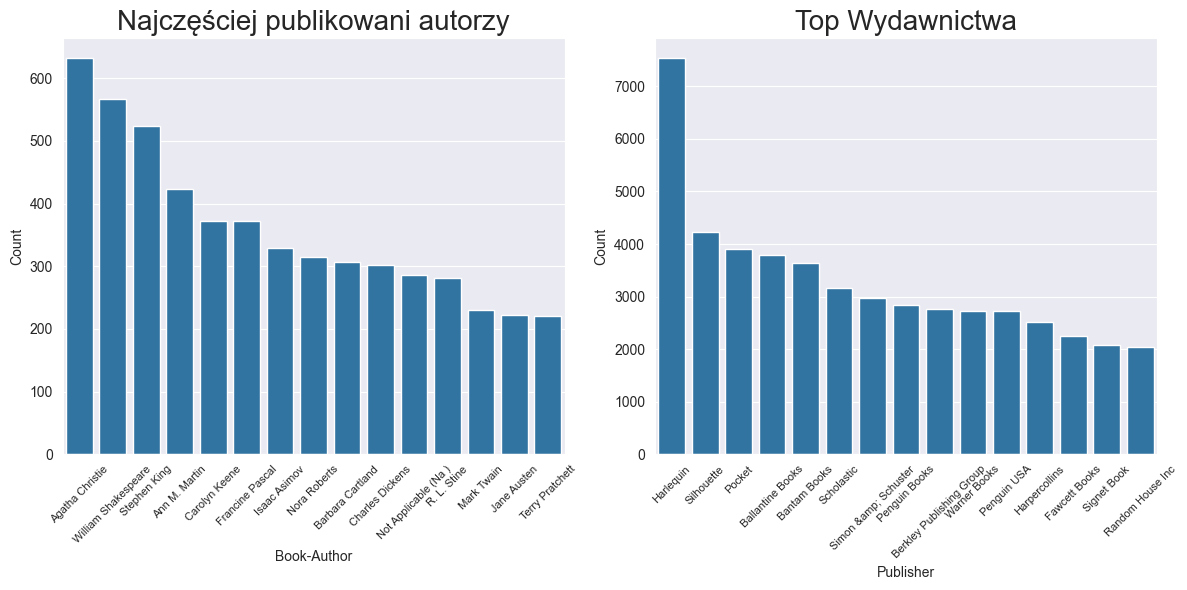

In [12]:
author_count = books_df['Book-Author'].value_counts().reset_index(name='Count').sort_values('Count', ascending=False).head(15)
publisher_count = books_df['Publisher'].value_counts().reset_index(name='Count').sort_values('Count', ascending=False).head(15)

fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,6))

sns.barplot(data=author_count, x='Book-Author', y='Count', ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, fontsize=8)
ax1.set_title('Najczęściej publikowani autorzy', size=20)

sns.barplot(data=publisher_count, x='Publisher', y='Count', ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, fontsize=8)
ax2.set_title('Top Wydawnictwa', size=20)

plt.tight_layout()

Wykres po lewej (Autorzy) wskazuje wyraźnie, że zbiór ten uwzględnia wielokrotne wydania tych samych książek (np. tłumaczenia, miękkie/twarde okładki, edycje specjalne). Stephen King czy Agatha Christie mają przypisane ogromne ilości pozycji.

Przyjrzyjmy się teraz rozkładowi wydawanych książek na przestrzeni lat.

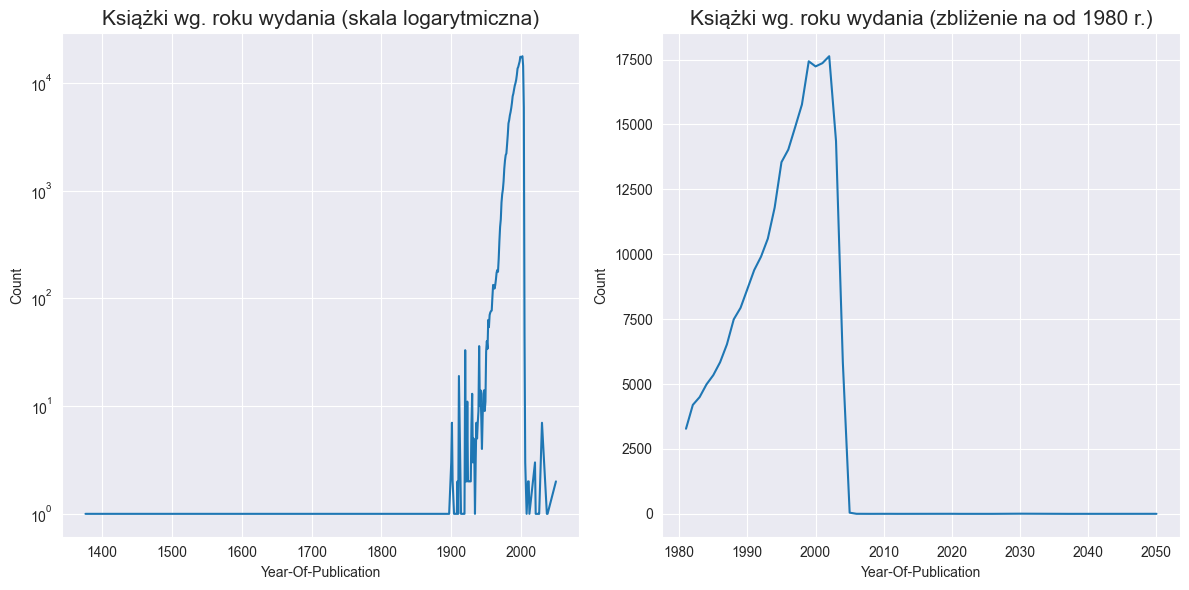

In [13]:
books_by_year = books_df[books_df['Year-Of-Publication'] != 0]['Year-Of-Publication'].value_counts().reset_index(name='Count').sort_values('Year-Of-Publication', ascending=True)

fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,6))

sns.lineplot(data=books_by_year, x='Year-Of-Publication', y='Count', ax=ax1)
ax1.set_yscale('log')
ax1.set_title('Książki wg. roku wydania (skala logarytmiczna)', fontsize=15)

sns.lineplot(data=books_by_year[books_by_year['Year-Of-Publication'] > 1980], x='Year-Of-Publication', y='Count', ax=ax2)
ax2.set_title('Książki wg. roku wydania (zbliżenie na od 1980 r.)', fontsize=15)

plt.tight_layout()

Gwałtowny spadek publikacji po roku 2005 sugeruje, że nasz zbiór danych (ang. *dataset*) został pobrany (zescrapowany) z internetu właśnie w tym okresie.

Zwróćmy uwagę na zachowania użytkowników – oceny i geografię bazy.

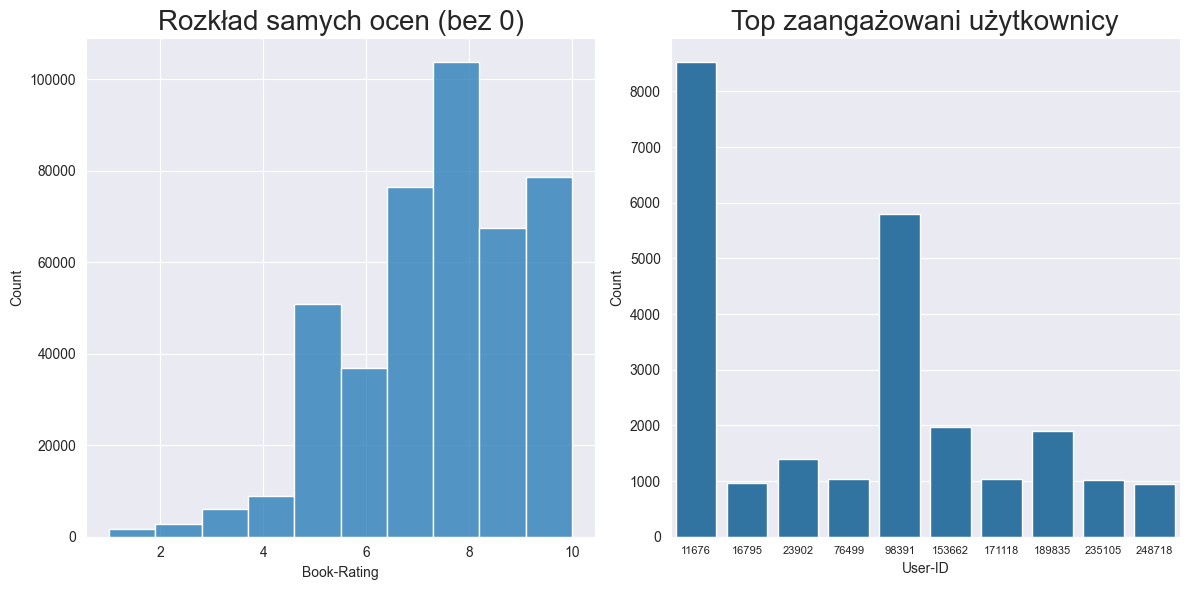

In [14]:
user_count = ratings_df_no_0['User-ID'].value_counts().reset_index(name='Count').sort_values(by='Count', ascending=False).head(10)

fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,6))

sns.histplot(ratings_df_no_0, x='Book-Rating', ax=ax1, bins=10)
ax1.set_title('Rozkład samych ocen (bez 0)', size=20)

sns.barplot(data=user_count, x='User-ID', y='Count', ax=ax2)
ax2.set_title('Top zaangażowani użytkownicy', size=20)
ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=8)

plt.tight_layout()

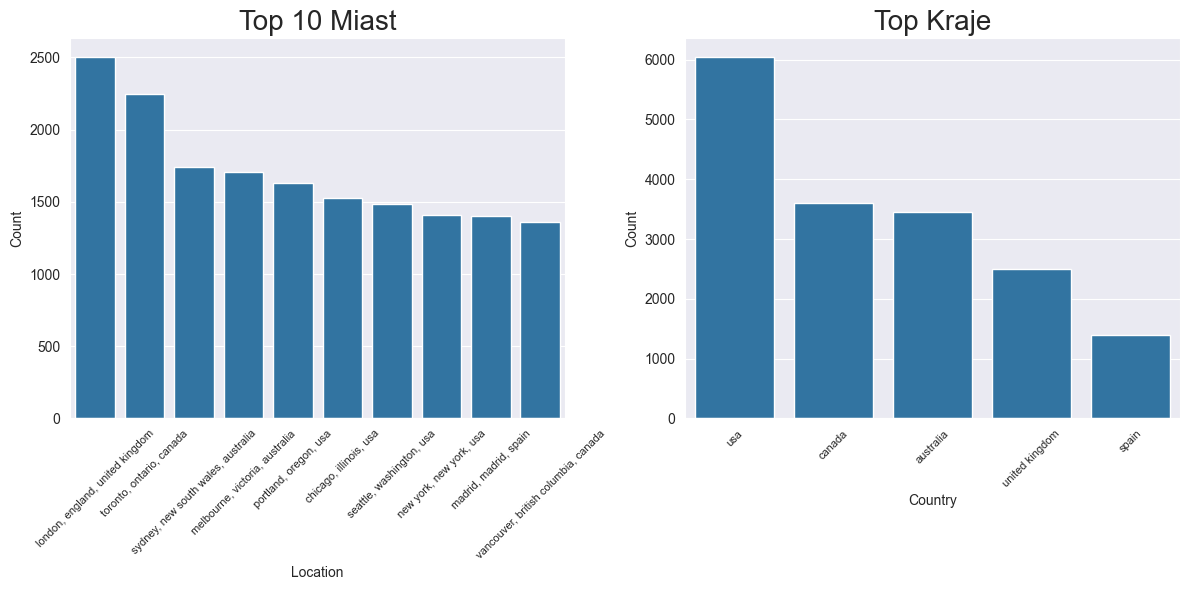

In [15]:
top_locations = users_df['Location'].value_counts().reset_index(name='Count').sort_values('Count', ascending=False).head(10)
top_locations['Country'] = top_locations['Location'].apply(lambda x: x.split(', ')[-1]) # Bezpieczniejszy split na ostatni element
top_countries = top_locations.groupby('Country')['Count'].sum().reset_index(name='Count').sort_values('Count', ascending=False).head(10)

fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,6))

sns.barplot(data=top_locations, x='Location', y='Count', ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, size=8)
ax1.set_title('Top 10 Miast', size=20)

sns.barplot(data=top_countries, x='Country', y='Count', ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, size=8)
ax2.set_title('Top Kraje', size=20)

plt.tight_layout()